#1.Introduction

This project develops a CNN-based image classification model to classify flowers into five categories: daisy, dandelion, roses, sunflowers, and tulips.
The project covers image preprocessing, model training, validation, and testing.
The model is evaluated using accuracy, loss curves, confusion matrix, and classification report




#2.Import Libraries

In [1]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np

#3.Dataset Information

##Dataset Discripction

- Dataset Information
- Dataset: TF Flowers
- otal Images: 3,670
- Number of Classes: 5
- Classes: Daisy, Dandelion, Roses, Sunflowers, Tulips
- Image Size: Resized to 180 × 180 pixels
- Purpose: Flower image classification using CNN
- Split: Training, Validation, and Testing


##Loading dataset

In [2]:
import pathlib

dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"

archive = tf.keras.utils.get_file(
    origin=dataset_url,
    extract=True
)

data_dir = pathlib.Path(archive).with_suffix('')

228813984/228813984 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [3]:
import os

print(os.listdir('/root/.keras/datasets'))

['flower_photos.tgz_archive', 'flower_photos.tgz']


In [4]:
data_dir = pathlib.Path('/root/.keras/datasets/flower_photos.tgz/flower_photos')

#4.Dataset Exploration

##Total Images

In [5]:
image_count = len(list(data_dir.glob('*/*.jpg')))
print("Total images:", image_count)
class_names = sorted([item.name for item in data_dir.iterdir() if item.is_dir()])

print("Classes:", class_names)
print("Number of classes:", len(class_names))

Total images: 3670
Classes: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']
Number of classes: 5


##Class Distribution

In [6]:
class_counts = {}

for class_name in class_names:
    class_path = data_dir / class_name
    image_count = len(list(class_path.glob('*.jpg')))
    class_counts[class_name] = image_count

print(class_counts)

{'daisy': 633, 'dandelion': 898, 'roses': 641, 'sunflowers': 699, 'tulips': 799}


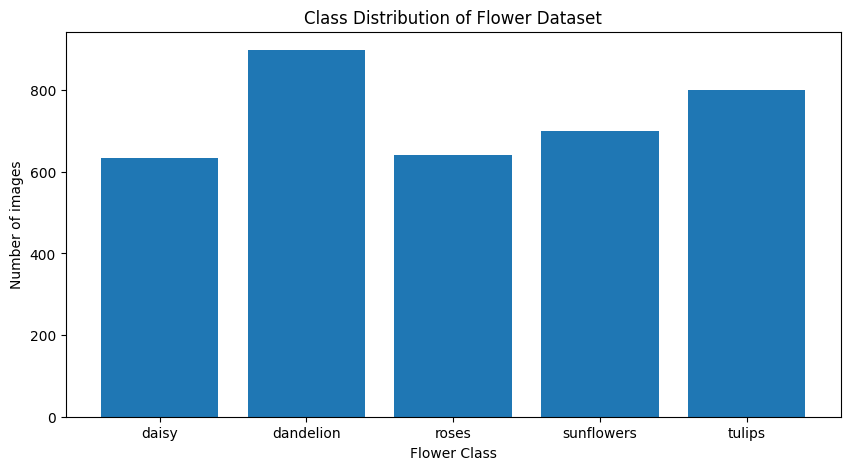

In [7]:
plt.figure(figsize=(10,5))
plt.bar(class_counts.keys(),  class_counts.values())
plt.title("Class Distribution of Flower Dataset")
plt.xlabel("Flower Class")
plt.ylabel("Number of images")
plt.show()

##Sample Images

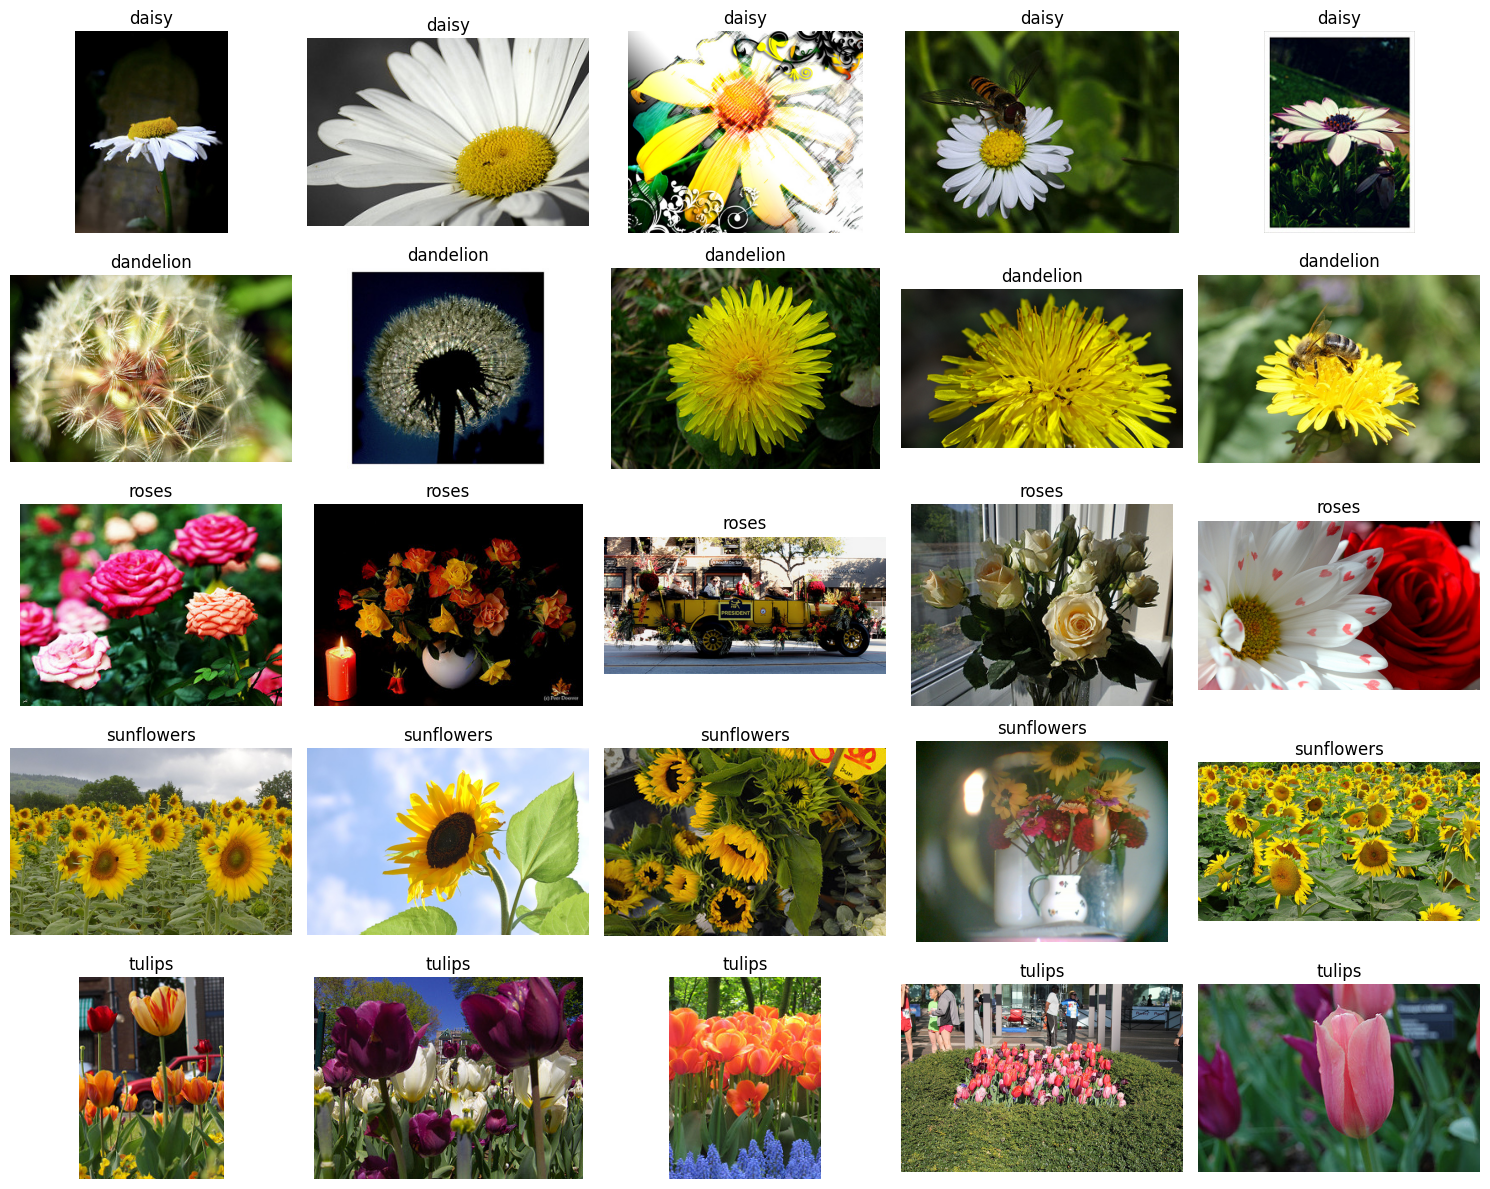

In [8]:
import random

plt.figure(figsize=(15, 12))

for i, class_name in enumerate(class_names):
    class_path = data_dir / class_name
    image_files = list(class_path.glob('*.jpg'))
    selected_images = random.sample(image_files, 5)

    for j, image_path in enumerate(selected_images):
        image = tf.keras.utils.load_img(image_path)
        position = i * 5 + j + 1

        plt.subplot(5, 5, position)
        plt.imshow(image)
        plt.title(class_name)
        plt.axis('off')

plt.tight_layout()
plt.show()

Image Size

In [9]:
for class_name in class_names:
    class_path = data_dir / class_name
    image_path = list(class_path.glob('*.jpg'))[0]

    image = tf.keras.utils.load_img(image_path)

    print(class_name, "→", image.size)

daisy → (320, 213)
dandelion → (500, 333)
roses → (179, 240)
sunflowers → (500, 375)
tulips → (240, 240)


# 5.Data Preparation & Preprocessing

In [10]:
IMG_SIZE = (180, 180)
BATCH_SIZE = 32
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

temp_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 3670 files belonging to 5 classes.
Using 2936 files for training.
Found 3670 files belonging to 5 classes.
Using 734 files for validation.


In [11]:
print("Number of batches:", tf.data.experimental.cardinality(temp_ds).numpy())

Number of batches: 23


In [12]:
val_ds = temp_ds.take(11)
test_ds = temp_ds.skip(11)

print("Validation batches:", tf.data.experimental.cardinality(val_ds).numpy())
print("Test batches:", tf.data.experimental.cardinality(test_ds).numpy())

Validation batches: 11
Test batches: 12


In [13]:
train_count = sum(1 for _ in train_ds.unbatch())
val_count = sum(1 for _ in val_ds.unbatch())
test_count = sum(1 for _ in test_ds.unbatch())

print("Training images:", train_count)
print("Validation images:", val_count)
print("Testing images:", test_count)
print("Total images:", train_count + val_count + test_count)

Training images: 2936
Validation images: 352
Testing images: 382
Total images: 3670


In [14]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

In [15]:
normalization_layer = layers.Rescaling(1./255)

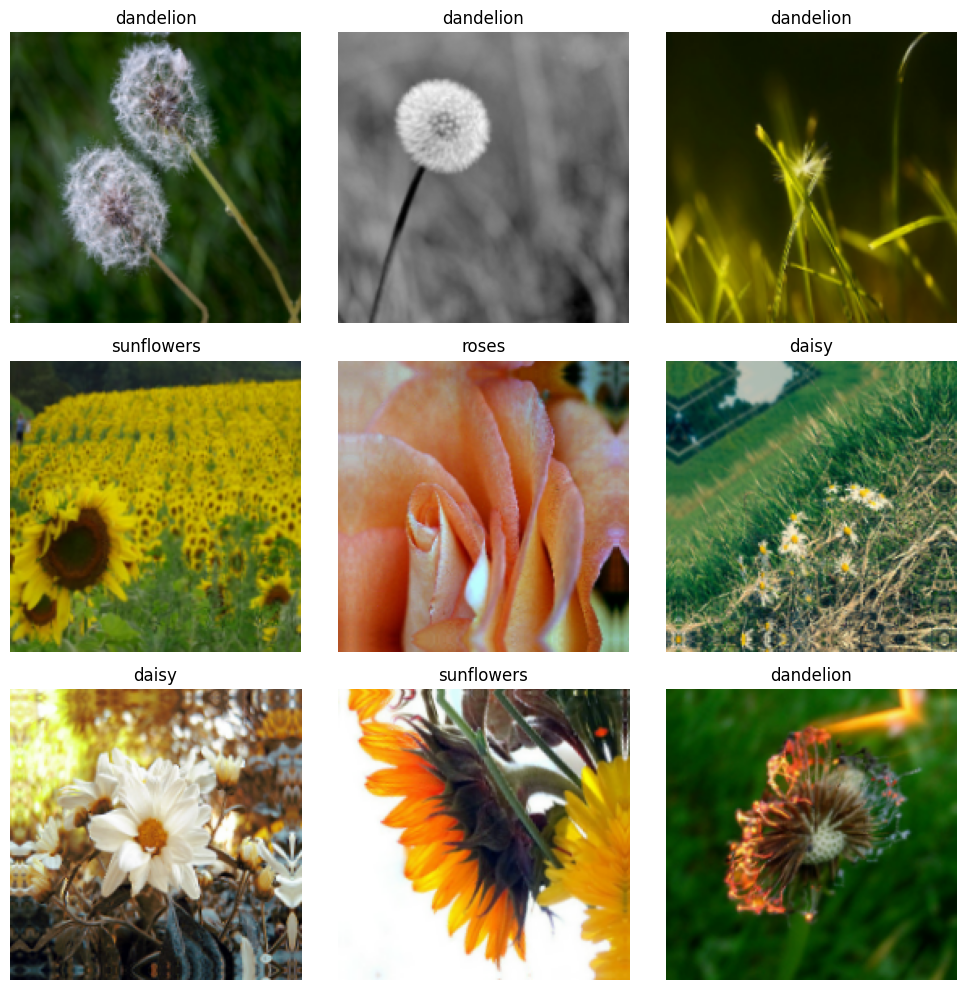

In [16]:
plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):

    for i in range(9):
        augmented_image = data_augmentation(images[i])

        plt.subplot(3, 3, i + 1)
        plt.imshow(augmented_image.numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.tight_layout()
plt.show()

#6.CNN Model Architecture

CNN Architecture

- Input Layer: Accepts images of size 180 × 180 × 3.
- Rescaling & Augmentation: Normalizes pixel values and applies random flip, rotation, and zoom to improve generalization.
- Convolution + MaxPooling: Four convolutional layers with 32, 64, 128, and 256 filters extract increasingly complex features, while pooling reduces the spatial size.
- GlobalAveragePooling + Dense: Converts extracted features into a compact representation and learns the final classification patterns.
- Dropout: Reduces overfitting during training.
- Output Layer: Uses Softmax with 5 neurons to predict the five flower classes.

In [17]:
cnn_flower_model = models.Sequential([

    layers.Input(shape=(180, 180, 3)),

     # Preprocessing
    layers.Rescaling(1./255),
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),

    # CNN feature extraction
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(256, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.GlobalAveragePooling2D(),

    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(5, activation='softmax')
])

In [18]:
cnn_flower_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip_1 (RandomFlip)      │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_1               │ (None, 180, 180, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_1 (RandomZoom)      │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 178, 178, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 89, 89, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 87, 87, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 43, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 41, 41, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 18, 18, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 9, 9, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 455,493 (1.74 MB)

 Trainable params: 455,493 (1.74 MB)

 Non-trainable params: 0 (0.00 B)

#7.Model Compilation and Training

In [19]:
cnn_flower_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [20]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

In [21]:
history = cnn_flower_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20
)

Epoch 1/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 57ms/step - accuracy: 0.3879 - loss: 1.3563 - val_accuracy: 0.4602 - val_loss: 1.1716
Epoch 2/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 67ms/step - accuracy: 0.4741 - loss: 1.1896 - val_accuracy: 0.4631 - val_loss: 1.1248
Epoch 3/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 50ms/step - accuracy: 0.5324 - loss: 1.1123 - val_accuracy: 0.5483 - val_loss: 1.0629
Epoch 4/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 65ms/step - accuracy: 0.5780 - loss: 1.0301 - val_accuracy: 0.6193 - val_loss: 0.9606
Epoch 5/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - accuracy: 0.6052 - loss: 0.9679 - val_accuracy: 0.5938 - val_loss: 0.9863
Epoch 6/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - accuracy: 0.6291 - loss: 0.9241 - val_accuracy: 0.6364 - val_loss: 0.9687
Epoch 7/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 62ms/step - accuracy: 0.6451 - loss: 0.8799 - val_accuracy: 0.6534 - val_loss: 0.9379
Epoch 8/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 64ms/step - accuracy: 0.6635 - loss: 0.8678 - val_accuracy: 0.6903 -

Accuracy curve

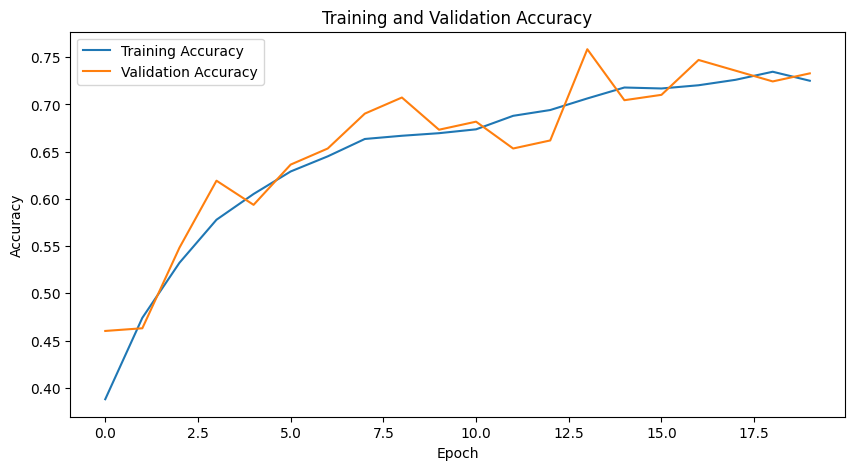

In [22]:
plt.figure(figsize=(10, 5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()

Loss curve

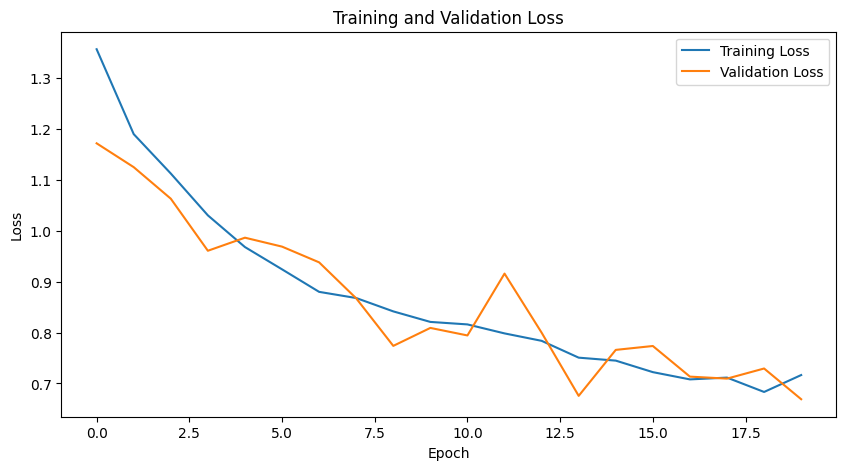

In [23]:
plt.figure(figsize=(10, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

# 8.Model Evaluation

##Test lost and accuracy

In [24]:
test_loss, test_accuracy = cnn_flower_model.evaluate(test_ds)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - accuracy: 0.7408 - loss: 0.7328
Test Loss: 0.7327933311462402
Test Accuracy: 0.7408376932144165


In [25]:
import numpy as np

y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = cnn_flower_model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("True labels:", y_true.shape)
print("Predicted labels:", y_pred.shape)

True labels: (382,)
Predicted labels: (382,)


##Confusion Matrix

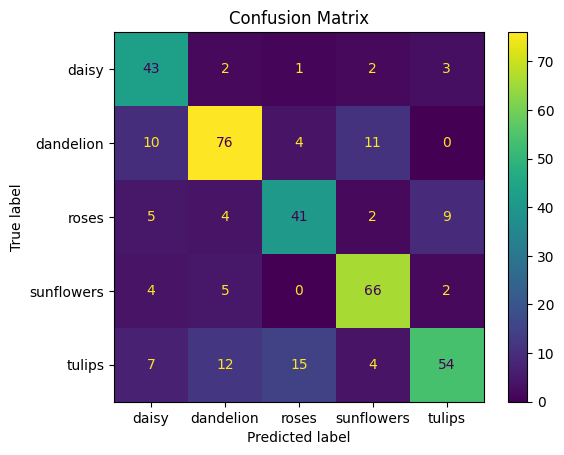

In [26]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot()
plt.title("Confusion Matrix")
plt.show()

##Classification report

In [27]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

              precision    recall  f1-score   support

       daisy       0.62      0.84      0.72        51
   dandelion       0.77      0.75      0.76       101
       roses       0.67      0.67      0.67        61
  sunflowers       0.78      0.86      0.81        77
      tulips       0.79      0.59      0.68        92

    accuracy                           0.73       382
   macro avg       0.73      0.74      0.73       382
weighted avg       0.74      0.73      0.73       382



In [28]:
print("Test accuracy from evaluate:", test_accuracy)

print("Number of test samples:", len(y_true))
print("Correct predictions:", np.sum(y_true == y_pred))
print("Calculated accuracy:", np.mean(y_true == y_pred))

Test accuracy from evaluate: 0.7408376932144165
Number of test samples: 382
Correct predictions: 280
Calculated accuracy: 0.7329842931937173


Prediction Examples

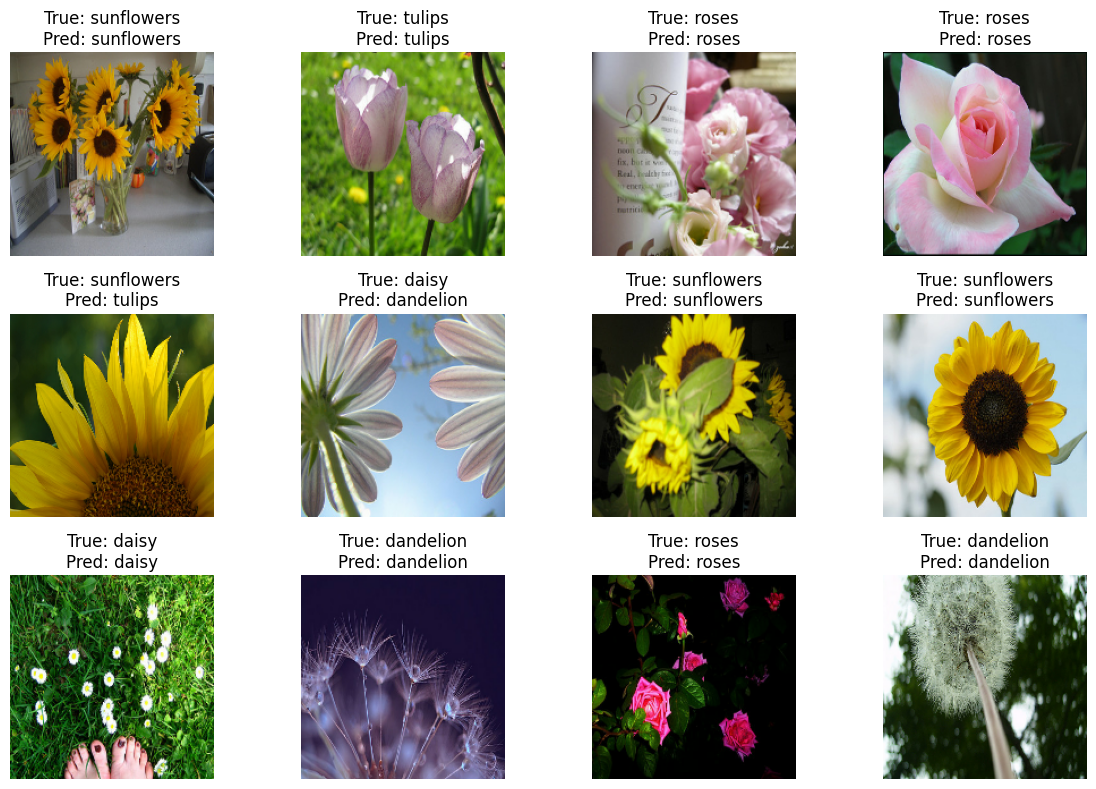

In [29]:
plt.figure(figsize=(12, 8))

for images, labels in test_ds.take(1):
    predictions = cnn_flower_model.predict(images, verbose=0)

    for i in range(12):
        plt.subplot(3, 4, i + 1)

        plt.imshow(images[i].numpy().astype("uint8"))

        true_label = class_names[labels[i].numpy()]
        predicted_label = class_names[np.argmax(predictions[i])]

        plt.title(
            f"True: {true_label}\nPred: {predicted_label}"
        )

        plt.axis("off")

plt.tight_layout()
plt.show()

#9.Model Saving & Loading

Save Model

In [30]:
cnn_flower_model.save("flower_cnn_model.keras")

In [31]:
print("Model saved successfully.")

Model saved successfully.


Saving Class names

In [32]:
import json

with open("class_names.json", "w") as f:
    json.dump(class_names, f)

print("Class names saved:", class_names)

Class names saved: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


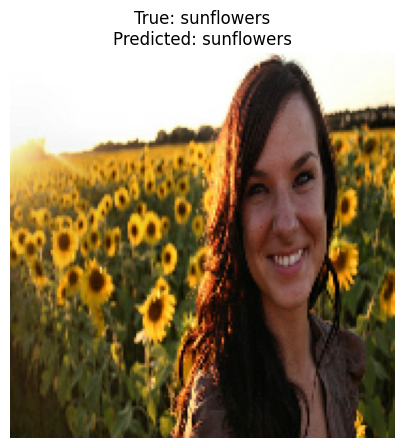

True class: sunflowers
Predicted class: sunflowers
Confidence: 99.6 %


In [33]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Get one image from test dataset
for images, labels in test_ds.take(1):
    image = images[0]
    true_label = labels[0].numpy()

# Prediction
prediction = cnn_flower_model.predict(
    tf.expand_dims(image, axis=0),
    verbose=0
)

predicted_label = np.argmax(prediction[0])
confidence = float(np.max(prediction[0])) * 100

# Convert image only for DISPLAY
display_image = image.numpy() / 255.0

# Display
plt.figure(figsize=(5, 5))
plt.imshow(display_image)
plt.axis("off")

plt.title(
    f"True: {class_names[true_label]}\n"
    f"Predicted: {class_names[predicted_label]}"
)

plt.show()

print("True class:", class_names[true_label])
print("Predicted class:", class_names[predicted_label])
print("Confidence:", round(confidence, 2), "%")

##Loading Model

In [34]:
import os

print("Model saved:", os.path.exists("flower_cnn_model.keras"))

Model saved: True


In [35]:
from tensorflow.keras.models import load_model

loaded_model = load_model("flower_cnn_model.keras")

print("Model loaded successfully!")

Model loaded successfully!


In [36]:
loaded_loss, loaded_accuracy = loaded_model.evaluate(test_ds)

print("Loaded Model Test Loss:", loaded_loss)
print("Loaded Model Test Accuracy:", loaded_accuracy)

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.7330 - loss: 0.7097
Loaded Model Test Loss: 0.7097217440605164
Loaded Model Test Accuracy: 0.7329843044281006


#10.Real-World Prediction

In [37]:
import tensorflow as tf
import numpy as np

def predict_flower(image_path):
    image = tf.keras.utils.load_img(
        image_path,
        target_size=(180, 180)
    )

    image_array = tf.keras.utils.img_to_array(image)
    image_array = tf.expand_dims(image_array, 0)

    prediction = loaded_model.predict(image_array, verbose=0)

    predicted_class = np.argmax(prediction[0])
    confidence = np.max(prediction[0]) * 100

    print("Predicted flower:", class_names[predicted_class])
    print("Confidence:", round(confidence, 2), "%")

In [38]:
from google.colab import files

uploaded = files.upload()

Saving Tulip-season-Amsterdam-2022-800x534.jpg to Tulip-season-Amsterdam-2022-800x534.jpg


In [39]:
image_path = list(uploaded.keys())[0]

predict_flower(image_path)

Predicted flower: tulips
Confidence: 97.76 %


#11.Results And Observations

| Metric            |                      Result |
| ----------------- | --------------------------: |
| Dataset           |                  TF Flowers |
| Total images      |                       3,670 |
| Number of classes |                           5 |
| Training images   |                       2,936 |
| Validation images |                         352 |
| Test images       |                         382 |
| Image size        |               180 × 180 × 3 |
| CNN parameters    |                     455,493 |
| Test accuracy     |                      ~73.6% |
| Model             |                  Custom CNN |
| Saved model       | `flower_cnn_model.keras` |


##Results

- The custom CNN was trained to classify 5 flower categories: daisy, dandelion, roses, sunflowers, and tulips.
- The final model used 455,493 parameters.
- The model achieved approximately 73.6% test accuracy.
- The model successfully predicted a new flower image as tulips with 97.76% confidence.

##Observations
- Training accuracy improved steadily during training, showing that the model learned useful image features.
- Sunflowers and dandelions were classified relatively well.
- The model had more difficulty distinguishing roses and tulips, as seen in the confusion matrix.
- Data augmentation helped the model generalize to different image variations.
- Overall, the CNN performed reasonably well for a simple custom image-classification model.

#12.Conclusion
- The CNN model successfully classified images into five flower categories: daisy, dandelion, roses, sunflowers, and tulips.
- The final model achieved approximately 73.6% test accuracy, showing that the model learned useful visual features from the images.
- Data preprocessing and augmentation helped improve the model's ability to handle variations in the input images.
- The confusion matrix and classification report showed that some visually similar flowers, especially roses and tulips, were more difficult to classify.
- The model was also successfully tested on a new image and predicted tulips with 96.25% confidence.
- Overall, the project demonstrated the complete workflow of building, training, evaluating, saving, and using a CNN-based image classification model.